In [1]:
import numpy as np
import pylab as pl
import ot
import time

In [2]:
data = np.load("data/manhattan.npz")

bakery_pos = data["bakery_pos"]
bakery_prod = data["bakery_prod"]
cafe_pos = data["cafe_pos"]
cafe_prod = data["cafe_prod"]
Imap = data["Imap"]

print("Bakery production: {}".format(bakery_prod))
print("Cafe sale: {}".format(cafe_prod))
print("Total croissants: {}".format(cafe_prod.sum()))

Bakery production: [31. 48. 82. 30. 40. 48. 89. 73.]
Cafe sale: [82. 88. 92. 88. 91.]
Total croissants: 441.0


## Plotting bakeries in the city

Text(0.5, 1.0, 'Mahattan Bakeries and Cafes')

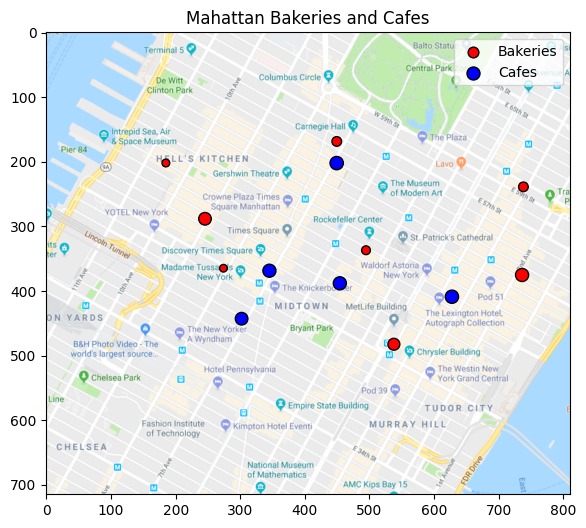

In [4]:
pl.figure(1, (7, 6))
pl.clf()
pl.imshow(Imap, interpolation="bilinear")
pl.scatter(bakery_pos[:, 0], bakery_pos[:, 1], s=bakery_prod, c="r", ec="k", label="Bakeries")
pl.scatter(cafe_pos[:, 0], cafe_pos[:, 1], s=cafe_prod, c="b", ec="k", label="Cafes")
pl.legend()
pl.title("Mahattan Bakeries and Cafes")

## Cost matrix

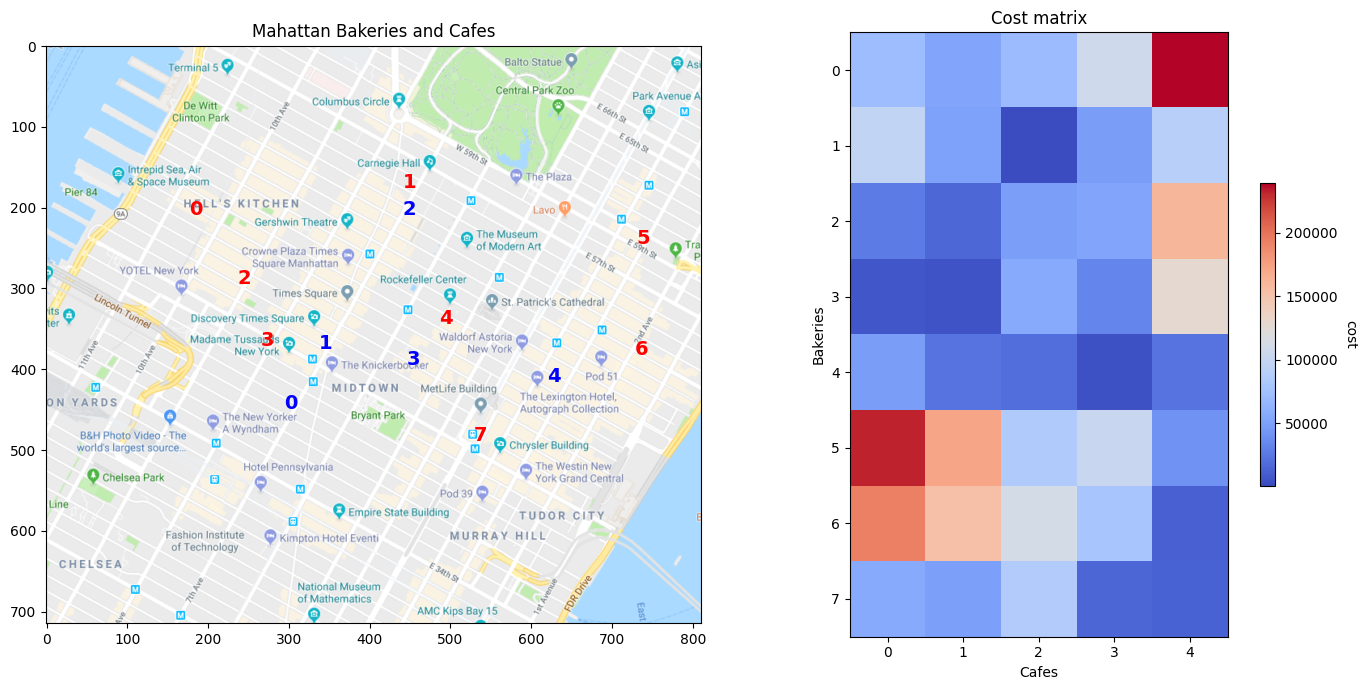

In [6]:
C = ot.dist(bakery_pos, cafe_pos)

labels = [str(i) for i in range(len(bakery_prod))]
f = pl.figure(2, (14, 7))
pl.clf()
pl.subplot(121)
pl.imshow(Imap, interpolation="bilinear")
for i in range(len(cafe_pos)):
  pl.text(
    cafe_pos[i, 0],
    cafe_pos[i, 1],
    labels[i],
    color="b",
    fontsize=14,
    fontweight="bold",
    ha="center",
    va="center"
	)

for i in range(len(bakery_pos)):
  pl.text(
    bakery_pos[i, 0],
    bakery_pos[i, 1],
    labels[i],
    color="r",
    fontsize=14,
    fontweight="bold",
    ha="center",
    va="center"
	)
pl.title("Mahattan Bakeries and Cafes")

ax = pl.subplot(122)
im = pl.imshow(C, cmap="coolwarm")
pl.title("Cost matrix")
cbar = pl.colorbar(im, ax=ax, shrink=0.5, use_gridspec=True)
cbar.ax.set_ylabel("cost", rotation=-90, va="bottom")

pl.xlabel("Cafes")
pl.ylabel("Bakeries")
pl.tight_layout()